**PART A: Frequency Forensics**

***
***
**FOURIER TRANSFORM OF THE IMAGE**
***
***

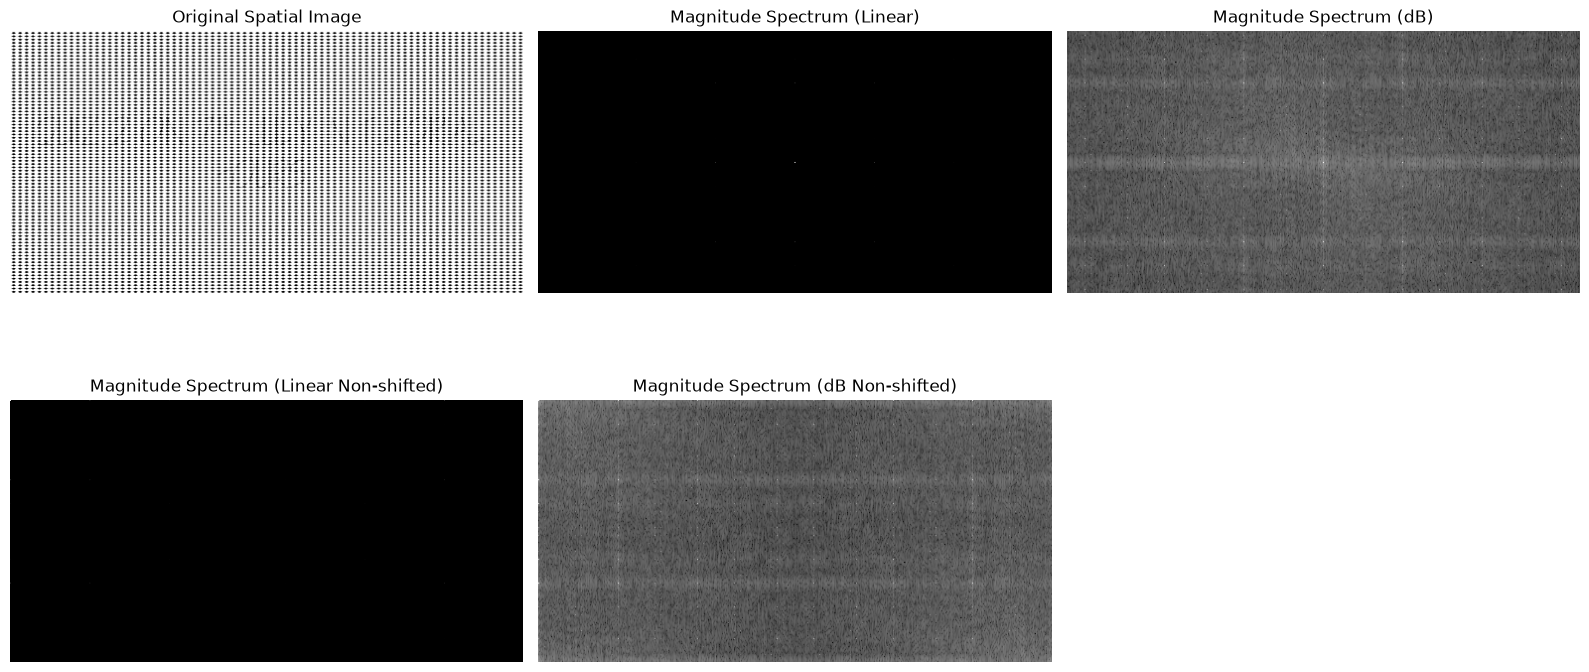

In [13]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the input image in grayscale
image_path = './EE200_course_project_data_2026/Q1_data/ghost_signal_input.png'
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Error: Image not found. Please ensure the file is in the same directory.")
else:
    # 2. Compute the 2D Discrete Fourier Transform
    f_transform = np.fft.fft2(image)

    # 3. Shift the zero-frequency (DC) component to the center of the spectrum
    f_shift = np.fft.fftshift(f_transform)

    # 4. Calculate the linear magnitude spectrum
    magnitude_linear = np.abs(f_shift)   #Shifted
    magnitude_linear_ns = np.abs(f_transform)   #Non-shifted

    # 5. Calculate the magnitude spectrum in decibels (dB)
    # A small constant (1) is added to prevent log(0) errors
    magnitude_db = 20 * np.log10(1 + magnitude_linear)   #Shifted
    magnitude_db_ns = 20 * np.log10(1 + magnitude_linear_ns)   #Non-shifted

    # 6. Plot the results
    plt.figure(figsize=(16, 8))

    plt.subplot(2, 3, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Original Spatial Image')
    plt.axis('off')

    plt.subplot(2, 3, 2)
    plt.imshow(magnitude_linear, cmap='gray')
    plt.title('Magnitude Spectrum (Linear)')
    plt.axis('off')

    plt.subplot(2, 3, 3)
    plt.imshow(magnitude_db, cmap='gray')
    plt.title('Magnitude Spectrum (dB)')
    plt.axis('off')

    plt.subplot(2, 3, 4)
    plt.imshow(magnitude_linear_ns, cmap='gray')
    plt.title('Magnitude Spectrum (Linear Non-shifted)')
    plt.axis('off')

    plt.subplot(2, 3, 5)
    plt.imshow(magnitude_db_ns, cmap='gray')
    plt.title('Magnitude Spectrum (dB Non-shifted)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

***
***
**DESIGN OF A NOTCH FILTER OR BAND-STOP FILTER**
***
***

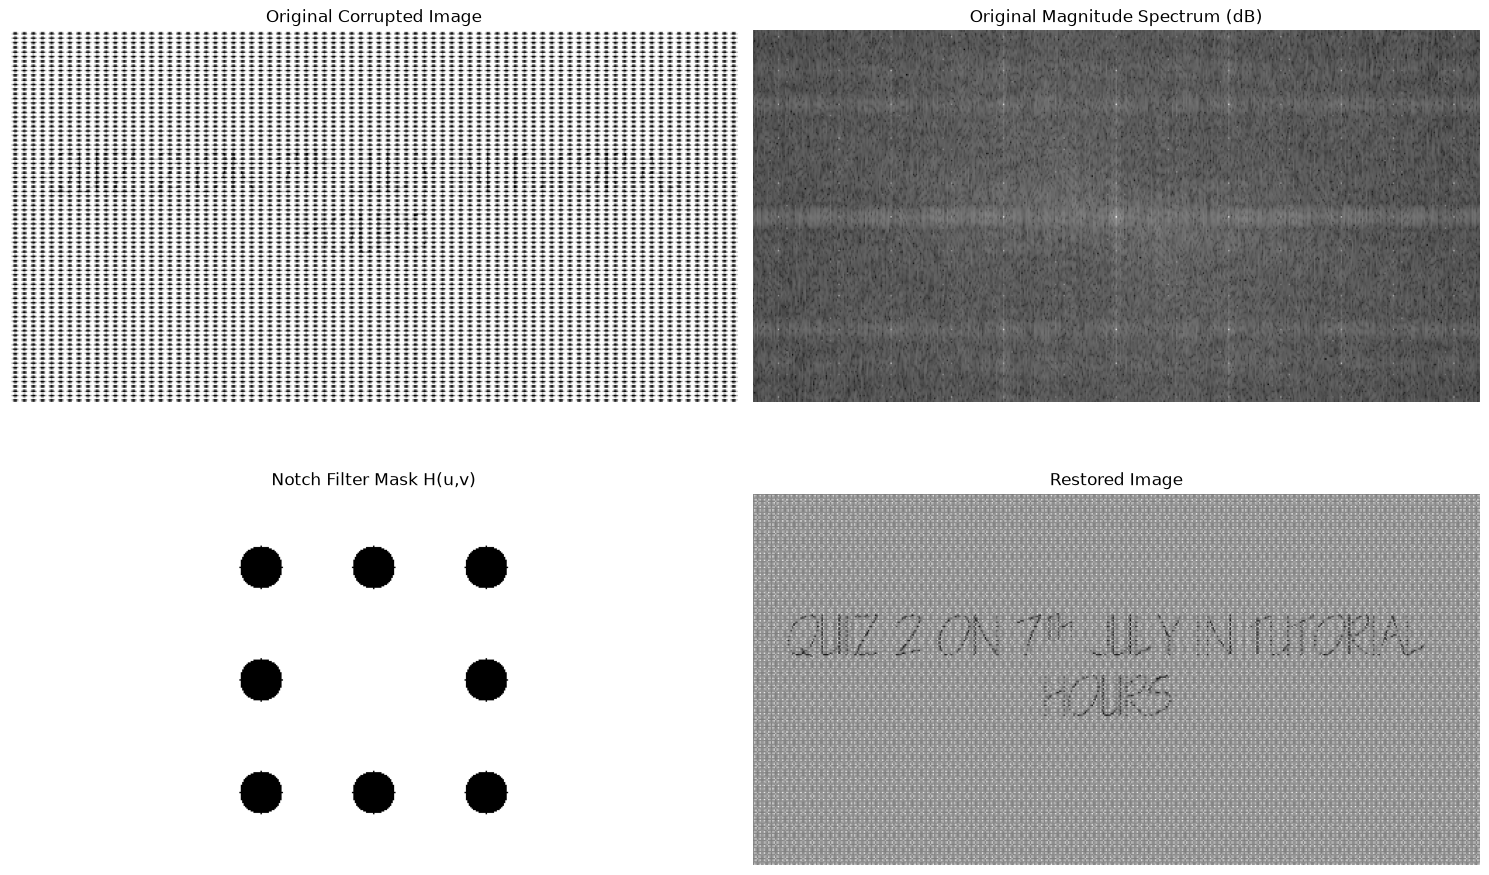

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def design_notch_filter(image_path, notch_radius=15, center_protection_radius=50):
    # 1. Load the image
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if image is None:
        print("Error: Image not found.")
        return

    rows, cols = image.shape
    center_row, center_col = rows // 2, cols // 2

    # 2. Transform into Frequency Domain
    f_transform = np.fft.fft2(image)
    f_shift = np.fft.fftshift(f_transform)
    magnitude_spectrum = np.abs(f_shift)

    # 3. Identify Noise Coordinates (Highest peaks outside the protected center)
    # We create a copy of the magnitude spectrum and zero out the center
    # so the DC component doesn't get identified as noise.
    mag_temp = np.copy(magnitude_spectrum)
    y, x = np.ogrid[:rows, :cols]
    center_mask = (y - center_row)**2 + (x - center_col)**2 <= center_protection_radius**2
    mag_temp[center_mask] = 0

    # For this example, let's find the top 4 mirrored spike pairs (8 total poles)
    # In a real scenario, you can adjust the number of peaks based on visual inspection
    num_peaks = 8 
    flat_indices = np.argsort(mag_temp.ravel())[-num_peaks:]
    peak_coords = [np.unravel_index(idx, mag_temp.shape) for idx in flat_indices]

    # 4. Create the Notch Filter Mask H(u,v)
    H = np.ones((rows, cols), np.float32)
    for (r, c) in peak_coords:
        # Create a circular notch of 0s around each noise peak
        notch = (y - r)**2 + (x - c)**2 <= notch_radius**2
        H[notch] = 0

    # 5. Apply the Filter
    G_shift = f_shift * H

    # 6. Inverse Transform to recover the image
    G_ishift = np.fft.ifftshift(G_shift)
    image_restored = np.fft.ifft2(G_ishift)
    image_restored = np.abs(image_restored)

    # Normalize the output for proper viewing
    image_restored = cv2.normalize(image_restored, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

    # 7. Plotting the Results
    plt.figure(figsize=(15, 10))

    plt.subplot(2, 2, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Original Corrupted Image')
    plt.axis('off')

    plt.subplot(2, 2, 2)
    # Log scale for visualization
    plt.imshow(20 * np.log10(1 + magnitude_spectrum), cmap='gray')
    plt.title('Original Magnitude Spectrum (dB)')
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.imshow(H, cmap='gray')
    plt.title('Notch Filter Mask H(u,v)')
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.imshow(image_restored, cmap='gray')
    plt.title('Restored Image')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    return image_restored, G_shift, magnitude_spectrum


recovered_img_GLOBAL, filtered_spectrum_GLOBAL, orig_spectrum_GLOBAL = design_notch_filter('./EE200_course_project_data_2026/Q1_data/ghost_signal_input.png')

***
***
**COMPARING THE CORRUPTED IMAGE, ITS FREQUENCY SPECTRUM, THE FILTERED SPECTRUM AND THE RECOVERED IMAGE**
***
***

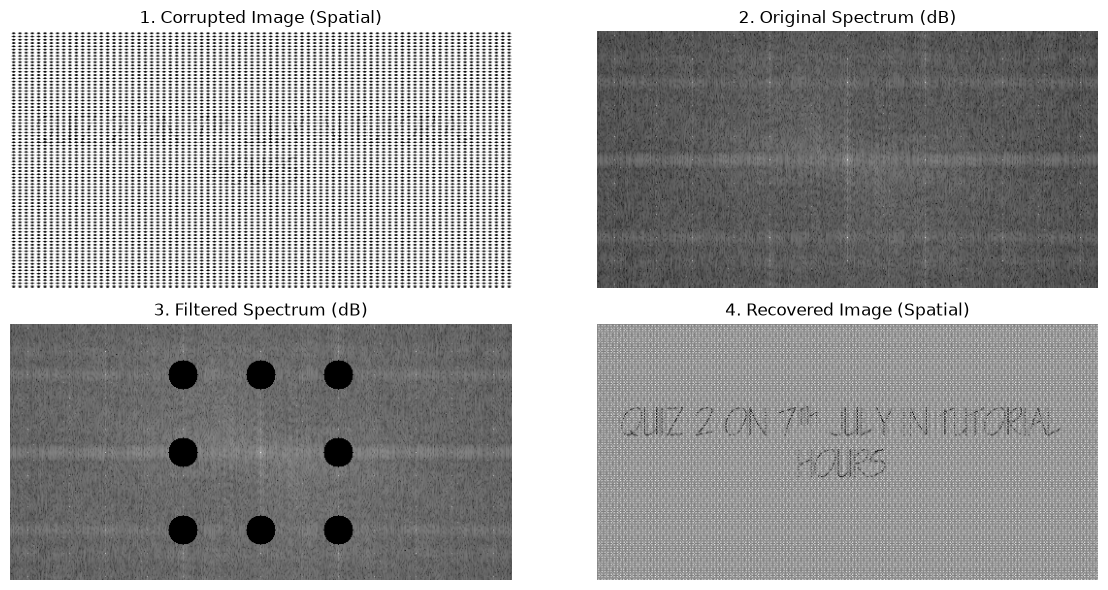

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming we have a modularized version of our previous filter function
# that returns the required arrays for visualization:
# original_img, orig_spectrum, filtered_spectrum, recovered_img = apply_notch_filter('ghost_signal_input.png')

def plot_comprehensive_comparison(original_img, orig_spectrum, filtered_spectrum, recovered_img):
    """
    Plots a side-by-side comparison of the spatial and frequency domains
    before and after applying the notch filter.
    """
    # Initialize a wide figure to hold 4 subplots sequentially
    plt.figure(figsize=(12, 6))

    # 1. The Original Corrupted Image
    plt.subplot(2, 2, 1)
    plt.imshow(original_img, cmap='gray')
    plt.title('1. Corrupted Image (Spatial)')
    plt.axis('off')

    # 2. The Original Frequency Spectrum
    # Logarithmic (dB) scale is used to make the noise spikes visible
    plt.subplot(2, 2, 2)
    plt.imshow(20 * np.log10(1 + orig_spectrum), cmap='gray')
    plt.title('2. Original Spectrum (dB)')
    plt.axis('off')

    # 3. The Filtered Frequency Spectrum
    # Shows the spectrum after the notch mask H(u,v) has zeroed out the spikes
    plt.subplot(2, 2, 3)
    plt.imshow(20 * np.log10(1 + filtered_spectrum), cmap='gray')
    plt.title('3. Filtered Spectrum (dB)')
    plt.axis('off')

    # 4. The Recovered Image
    plt.subplot(2, 2, 4)
    plt.imshow(recovered_img, cmap='gray')
    plt.title('4. Recovered Image (Spatial)')
    plt.axis('off')

    # Adjust layout to prevent overlapping titles and display the plot
    plt.tight_layout()
    plt.show()

# Execute the visualization function using the variables extracted from the system
# plot_comprehensive_comparison(original_img, orig_spectrum, filtered_spectrum, recovered_img)

plot_comprehensive_comparison(image, orig_spectrum_GLOBAL, np.abs(filtered_spectrum_GLOBAL), recovered_img_GLOBAL)

**PART B: Digital Detective**

***
***
**APPYING SOBEL FILTER TO THE IMAGE**
***
***

In [27]:
!pip install scipy

   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   - -------------------------------------- 1.3/36.6 MB 11.2 MB/s eta 0:00:04
   ----- ---------------------------------- 5.0/36.6 MB 14.4 MB/s eta 0:00:03
   -------- ------------------------------- 8.1/36.6 MB 14.8 MB/s eta 0:00:02
   ------------ --------------------------- 11.5/36.6 MB 15.3 MB/s eta 0:00:02
   ---------------- ----------------------- 15.2/36.6 MB 15.9 MB/s eta 0:00:02
   -------------------- ------------------- 18.9/36.6 MB 16.1 MB/s eta 0:00:02
   ------------------------ --------------- 22.5/36.6 MB 16.4 MB/s eta 0:00:01
   ---------------------------- ----------- 26.0/36.6 MB 16.4 MB/s eta 0:00:01
   ------------------------------ --------- 28.3/36.6 MB 15.7 MB/s eta 0:00:01
   ---------------------------------- ----- 32.0/36.6 MB 16.1 MB/s eta 0:00:01
   ---------------------------------------  35.9/36.6 MB 16.3 MB/s eta 0:00:01
   ---------------------------------------- 36.6/36.6 MB 15.7 MB

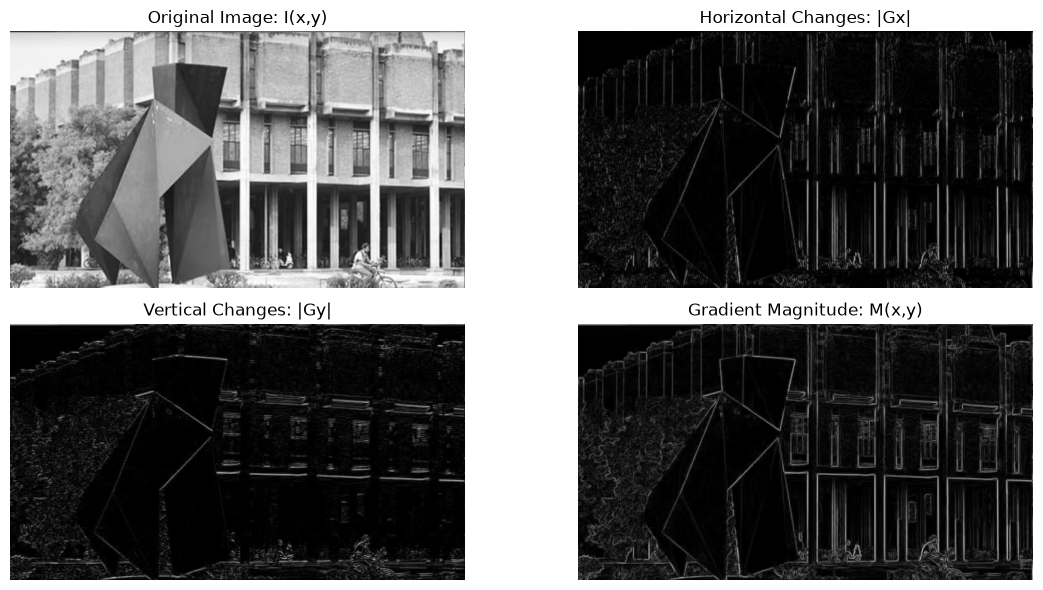

In [36]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

# 1. Load the spatial image
# Assuming the image is saved locally as 'missing_boundaries_input.avif'
# We load it in grayscale to process the 2D intensity signal I(x,y)
img_pil = Image.open('./EE200_course_project_data_2026/Q1_data/missing_boundaries_input.avif').convert('L') # Convert to grayscale
image = np.array(img_pil)

if image is None:
    print("Error: Could not load the image. Please check the file path.")
else:
    # Convert image matrix to float64 to prevent data overflow during derivative calculations
    image_float = np.float64(image)

    # 2. Define the Sobel Kernels
    # Kernel for horizontal derivative (detects vertical edges)
    sobel_x = np.array([[-1, 0, 1],
                        [-2, 0, 2],
                        [-1, 0, 1]])

    # Kernel for vertical derivative (detects horizontal edges)
    sobel_y = np.array([[-1, -2, -1],
                        [ 0,  0,  0],
                        [ 1,  2,  1]])

    # 3. Perform Discrete 2D Convolution
    # 'boundary=symm' handles edge pixels to avoid artifacts
    # 'mode=same' ensures the output gradient matrices match the original image dimensions
    grad_x = convolve2d(image_float, sobel_x, boundary='symm', mode='same')
    grad_y = convolve2d(image_float, sobel_y, boundary='symm', mode='same')

    # 4. Calculate Gradient Magnitude (Edge Strength)
    # M(x,y) = sqrt(Gx^2 + Gy^2)
    gradient_magnitude = np.sqrt(grad_x**2 + grad_y**2)

    # Normalize the final magnitude matrix to an 8-bit scale (0-255) for standard visual display
    gradient_magnitude_display = np.uint8(255 * gradient_magnitude / np.max(gradient_magnitude))

    # 5. Visualize the Processing Pipeline
    plt.figure(figsize=(12, 6))

    # Plot Original Image
    plt.subplot(2, 2, 1)
    plt.imshow(image, cmap='gray')
    plt.title('Original Image: I(x,y)')
    plt.axis('off')

    # Plot Absolute Horizontal Gradient
    plt.subplot(2, 2, 2)
    plt.imshow(np.abs(grad_x), cmap='gray')
    plt.title('Horizontal Changes: |Gx|')
    plt.axis('off')

    # Plot Absolute Vertical Gradient
    plt.subplot(2, 2, 3)
    plt.imshow(np.abs(grad_y), cmap='gray')
    plt.title('Vertical Changes: |Gy|')
    plt.axis('off')

    # Plot Final Edge Map (Magnitude)
    plt.subplot(2, 2, 4)
    plt.imshow(gradient_magnitude_display, cmap='gray')
    plt.title('Gradient Magnitude: M(x,y)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()